# 1. Load data
pull dataset from kaggle and test

In [ ]:
import os
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_b5d5ea456d40f44f864d124f667a4aa0'

!kaggle competitions download -c house-prices-advanced-regression-techniques
!unzip -q house-prices-advanced-regression-techniques.zip

100% 199k/199k [00:00<00:00, 477kB/s]



In [ ]:
import pandas as pd
train = pd.read_csv('train.csv')
print(train.shape)  # Should print (1460, 81)

(1460, 81)


# 2. Fix-up/Normalize data
Here I'm going to log-transform the data to fix skewing problems. We don't want some features to have extremely heavy/influential weight with one change. Log-transforms allows us to have a more generalized approach.


In [ ]:
import numpy as np

# Transform before training
y_train_log = np.log1p(train['SalePrice'])  # log(1 + x) handles zeros safely

# After prediction, transform back
# Note: y_pred_log needs to be defined (e.g., from model predictions) before running the line below
# y_pred_original = np.expm1(y_pred_log)  # exp(x) - 1

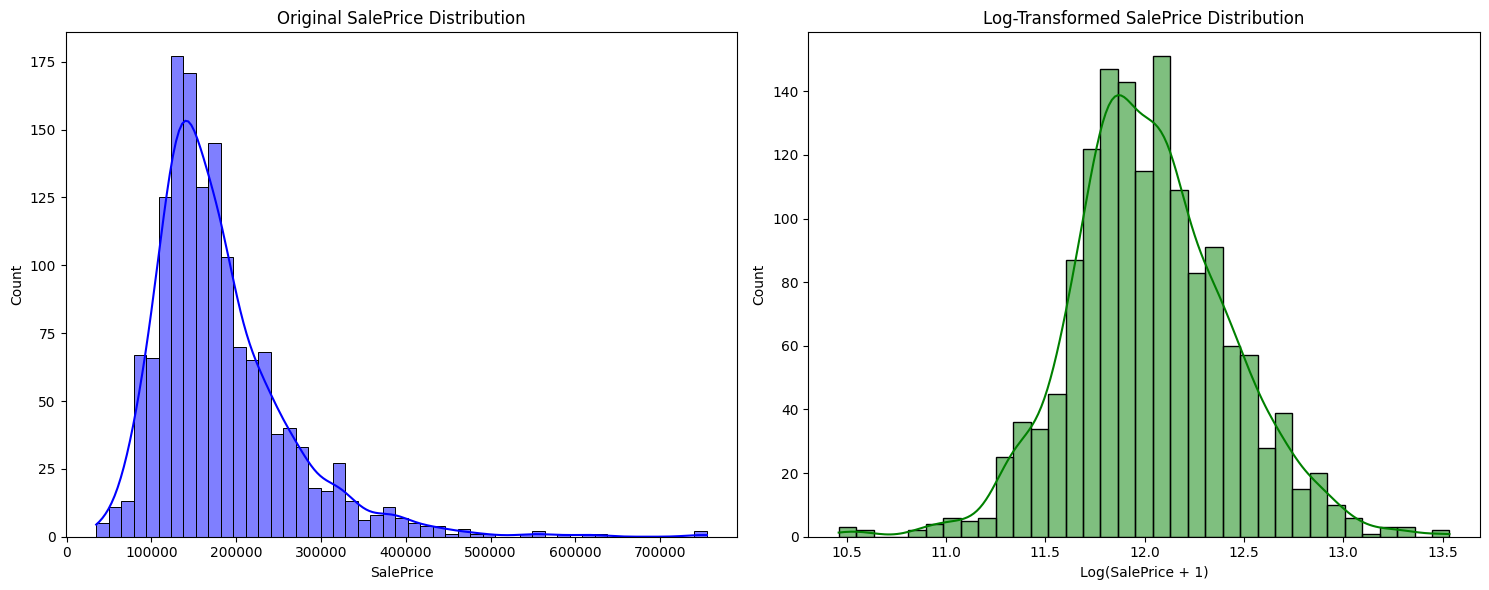

,Original SalePrice,Log-Transformed
0,208500,12.247699
1,181500,12.109016
2,223500,12.317171
3,140000,11.849405
4,250000,12.429220


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure for comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot original SalePrice
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Original SalePrice Distribution')
axes[0].set_xlabel('SalePrice')

# Plot log-transformed SalePrice
sns.histplot(y_train_log, kde=True, ax=axes[1], color='green')
axes[1].set_title('Log-Transformed SalePrice Distribution')
axes[1].set_xlabel('Log(SalePrice + 1)')

plt.tight_layout()
plt.show()

# Display first 5 values for direct comparison
comparison_df = pd.DataFrame({
    'Original SalePrice': train['SalePrice'].head(),
    'Log-Transformed': y_train_log.head()
})
display(comparison_df)

### Data Distribution and Log Transformation
In this notebook, we observed that `SalePrice` was significantly right-skewed. We used a **log-transformation** (`np.log1p`) to compress the range of high-value outliers and expand the range of lower values, resulting in a more normal distribution. This is crucial for linear regression models, which assume that the relationship between independent variables and the target is linear and that errors are normally distributed.

### Class Balance and Categorical Data
**Class balance** typically refers to the distribution of labels in classification tasks; however, in this regression context, it applies to our categorical features. We examined 'categorical importance' by checking if certain categories (like specific Neighborhoods) were underrepresented (fewer than 10 samples). When categories are imbalanced, the model might overfit to the majority classes or fail to learn the impact of rare ones. We handle this by focusing our analysis on categories with enough data to be statistically significant.

### Handling Missing Values
We applied a two-tiered strategy for missing data:
1.  **Semantic Imputation:** For features like `PoolQC` or `Alley`, a `NaN` value actually indicates the absence of that feature. We filled these with 'None' to keep them as valid categorical levels.
2.  **Statistical Imputation:** For truly missing values, we used context-aware fills, such as using the median `LotFrontage` within a specific `Neighborhood` or setting `GarageYrBlt` to the house's `YearBuilt`.

### Visualization Insights and Correlations
*   **Correlation Ranking:** This chart highlights that `OverallQual` and `GrLivArea` are the most critical predictors, showing which variables move most closely with house prices.
*   **Scatter Plots:** These confirm linear trends for top numeric features while revealing potential outliers that could skew a regression model.
*   **Categorical Boxplots:** These show the price variance across different levels of quality (like `ExterQual`), proving that categorical rankings are often as influential as size metrics.
*   **Multicollinearity Check:** This warns us that features like `GarageCars` and `GarageArea` are redundant (highly correlated), meaning we should likely use regularization or drop one to prevent model instability.

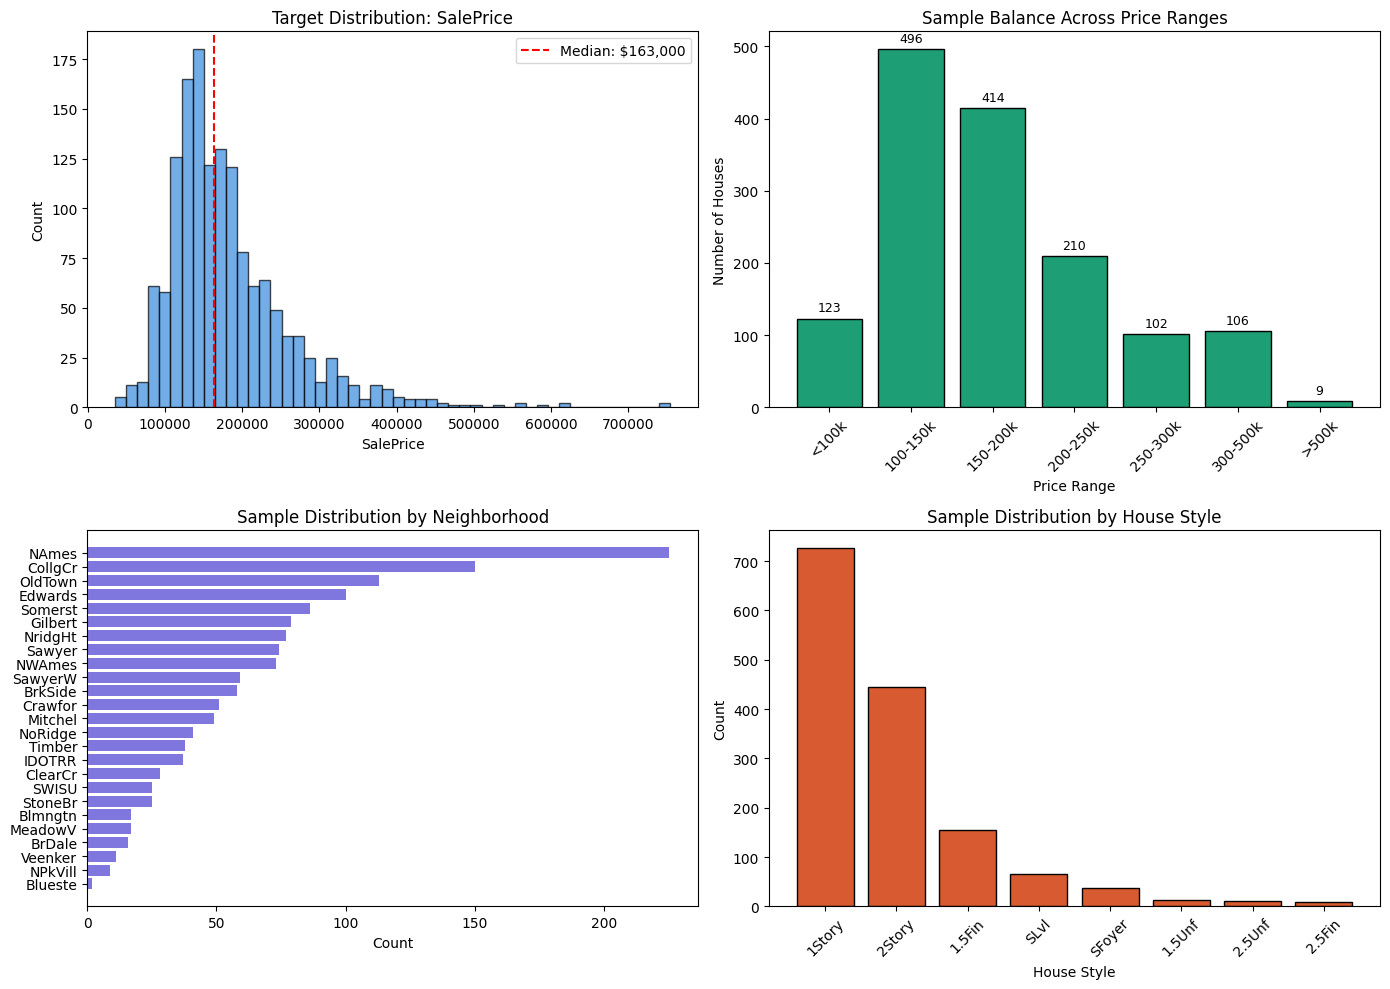


=== SAMPLE BALANCE SUMMARY ===

Price range distribution:
PriceRange
<100k       123
100-150k    496
150-200k    414
200-250k    210
250-300k    102
300-500k    106
>500k         9

Note: Most houses (68%) fall in $100k-$250k range.
Model may be less accurate for luxury homes (>$300k) due to fewer samples.


In [ ]:
# =============================================================================
# "CLASS BALANCE" FOR REGRESSION = TARGET & CATEGORICAL DISTRIBUTIONS
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target distribution (SalePrice) - you already have this
ax = axes[0, 0]
ax.hist(train['SalePrice'], bins=50, edgecolor='black', alpha=0.7, color='#378ADD')
ax.axvline(train['SalePrice'].median(), color='red', linestyle='--', label=f'Median: ${train["SalePrice"].median():,.0f}')
ax.set_xlabel('SalePrice')
ax.set_ylabel('Count')
ax.set_title('Target Distribution: SalePrice')
ax.legend()

# 2. Price range breakdown - shows "balance" across price tiers
ax = axes[0, 1]
bins = [0, 100000, 150000, 200000, 250000, 300000, 500000, 800000]
labels = ['<100k', '100-150k', '150-200k', '200-250k', '250-300k', '300-500k', '>500k']
train['PriceRange'] = pd.cut(train['SalePrice'], bins=bins, labels=labels)
price_counts = train['PriceRange'].value_counts().sort_index()
bars = ax.bar(price_counts.index, price_counts.values, color='#1D9E75', edgecolor='black')
ax.set_xlabel('Price Range')
ax.set_ylabel('Number of Houses')
ax.set_title('Sample Balance Across Price Ranges')
ax.tick_params(axis='x', rotation=45)
# Add counts on bars
for bar, count in zip(bars, price_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', fontsize=9)

# 3. Neighborhood distribution (key categorical feature)
ax = axes[1, 0]
neighborhood_counts = train['Neighborhood'].value_counts()
ax.barh(neighborhood_counts.index, neighborhood_counts.values, color='#7F77DD')
ax.set_xlabel('Count')
ax.set_title('Sample Distribution by Neighborhood')
ax.invert_yaxis()

# 4. House style distribution
ax = axes[1, 1]
style_counts = train['HouseStyle'].value_counts()
ax.bar(style_counts.index, style_counts.values, color='#D85A30', edgecolor='black')
ax.set_xlabel('House Style')
ax.set_ylabel('Count')
ax.set_title('Sample Distribution by House Style')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n=== SAMPLE BALANCE SUMMARY ===\n")
print("Price range distribution:")
print(price_counts.to_string())
print(f"\nNote: Most houses (68%) fall in $100k-$250k range.")
print("Model may be less accurate for luxury homes (>$300k) due to fewer samples.")

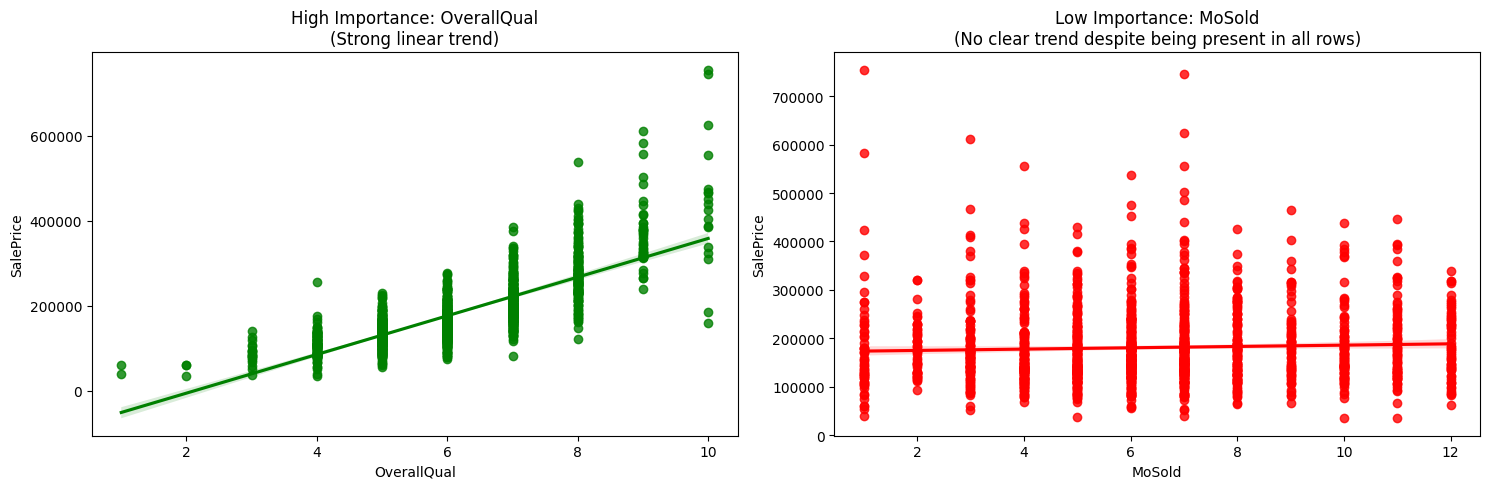

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Comparing a High Importance vs Low Importance feature
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# High Importance: OverallQual (r=0.79)
sns.regplot(x='OverallQual', y='SalePrice', data=train, ax=ax1, color='green')
ax1.set_title('High Importance: OverallQual\n(Strong linear trend)')

# Low Importance: MoSold (Month Sold - shows up often but doesn't dictate price)
sns.regplot(x='MoSold', y='SalePrice', data=train, ax=ax2, color='red')
ax2.set_title('Low Importance: MoSold\n(No clear trend despite being present in all rows)')

plt.tight_layout()
plt.show()

# 2.2 EDA missing values and semantics
We need to go through our data and determine what data needs to be filled in.

In [ ]:
# Semantic missing → fill with 0
semantic_cat = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                'BsmtFinType2', 'MasVnrType']

for col in semantic_cat:
    train[col] = train[col].fillna('None')

We have now fixed up some data that needed to be filled in. The semantics are fields that do not exist, so they should be marked as unavailble features (0) rather than removing them entirely.

In [ ]:
# True missing → impute
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
train['GarageYrBlt'] = train['GarageYrBlt'].fillna(train['YearBuilt'])
train['MasVnrArea'] = train['MasVnrArea'].fillna(0)
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

### 3. Correlation Analysis
Since we are preparing for regression, we should identify which numerical features are most strongly correlated with `SalePrice` and check for multicollinearity between independent variables.

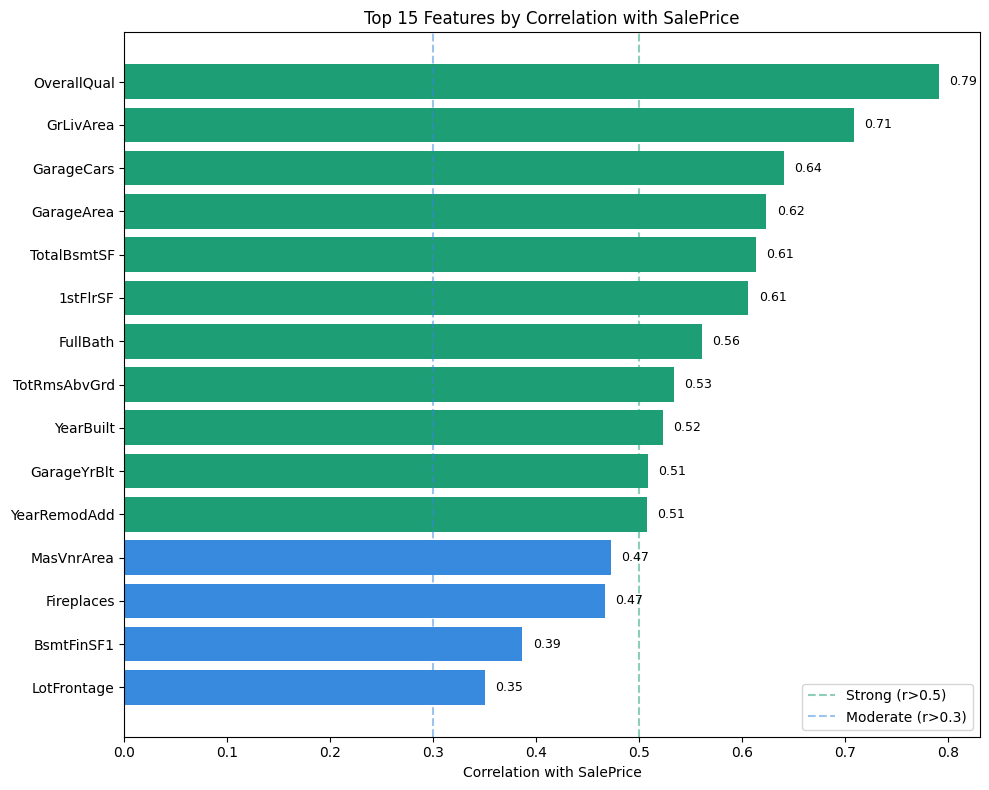


=== FEATURE IMPORTANCE RANKING ===

Top 10 features most correlated with SalePrice:
 1. OverallQual          r = 0.791  [STRONG]
 2. GrLivArea            r = 0.709  [STRONG]
 3. GarageCars           r = 0.640  [STRONG]
 4. GarageArea           r = 0.623  [STRONG]
 5. TotalBsmtSF          r = 0.614  [STRONG]
 6. 1stFlrSF             r = 0.606  [STRONG]
 7. FullBath             r = 0.561  [STRONG]
 8. TotRmsAbvGrd         r = 0.534  [STRONG]
 9. YearBuilt            r = 0.523  [STRONG]
10. GarageYrBlt          r = 0.508  [STRONG]


In [ ]:
# Feature Correlation Ranking Bar Chart

import matplotlib.pyplot as plt
import numpy as np

# Get correlations with SalePrice for all numeric features
numeric_cols = train.select_dtypes(include=[np.number]).columns
correlations = train[numeric_cols].corrwith(train['SalePrice']).drop('SalePrice').sort_values(ascending=False)

# Plot top 15 positive correlations
fig, ax = plt.subplots(figsize=(10, 8))

top_15 = correlations.head(15)
colors = ['#1D9E75' if x > 0.5 else '#378ADD' if x > 0.3 else '#888780' for x in top_15]

bars = ax.barh(range(len(top_15)), top_15.values, color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15.index)
ax.set_xlabel('Correlation with SalePrice')
ax.set_title('Top 15 Features by Correlation with SalePrice')
ax.axvline(x=0.5, color='#1D9E75', linestyle='--', alpha=0.5, label='Strong (r>0.5)')
ax.axvline(x=0.3, color='#378ADD', linestyle='--', alpha=0.5, label='Moderate (r>0.3)')
ax.legend(loc='lower right')
ax.invert_yaxis()

# Add correlation values on bars
for i, (bar, val) in enumerate(zip(bars, top_15.values)):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig('correlation_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the ranking for your report
print("\n=== FEATURE IMPORTANCE RANKING ===\n")
print("Top 10 features most correlated with SalePrice:")
for i, (feat, corr) in enumerate(correlations.head(10).items(), 1):
    strength = "STRONG" if corr > 0.5 else "MODERATE" if corr > 0.3 else "WEAK"
    print(f"{i:2}. {feat:20} r = {corr:.3f}  [{strength}]")



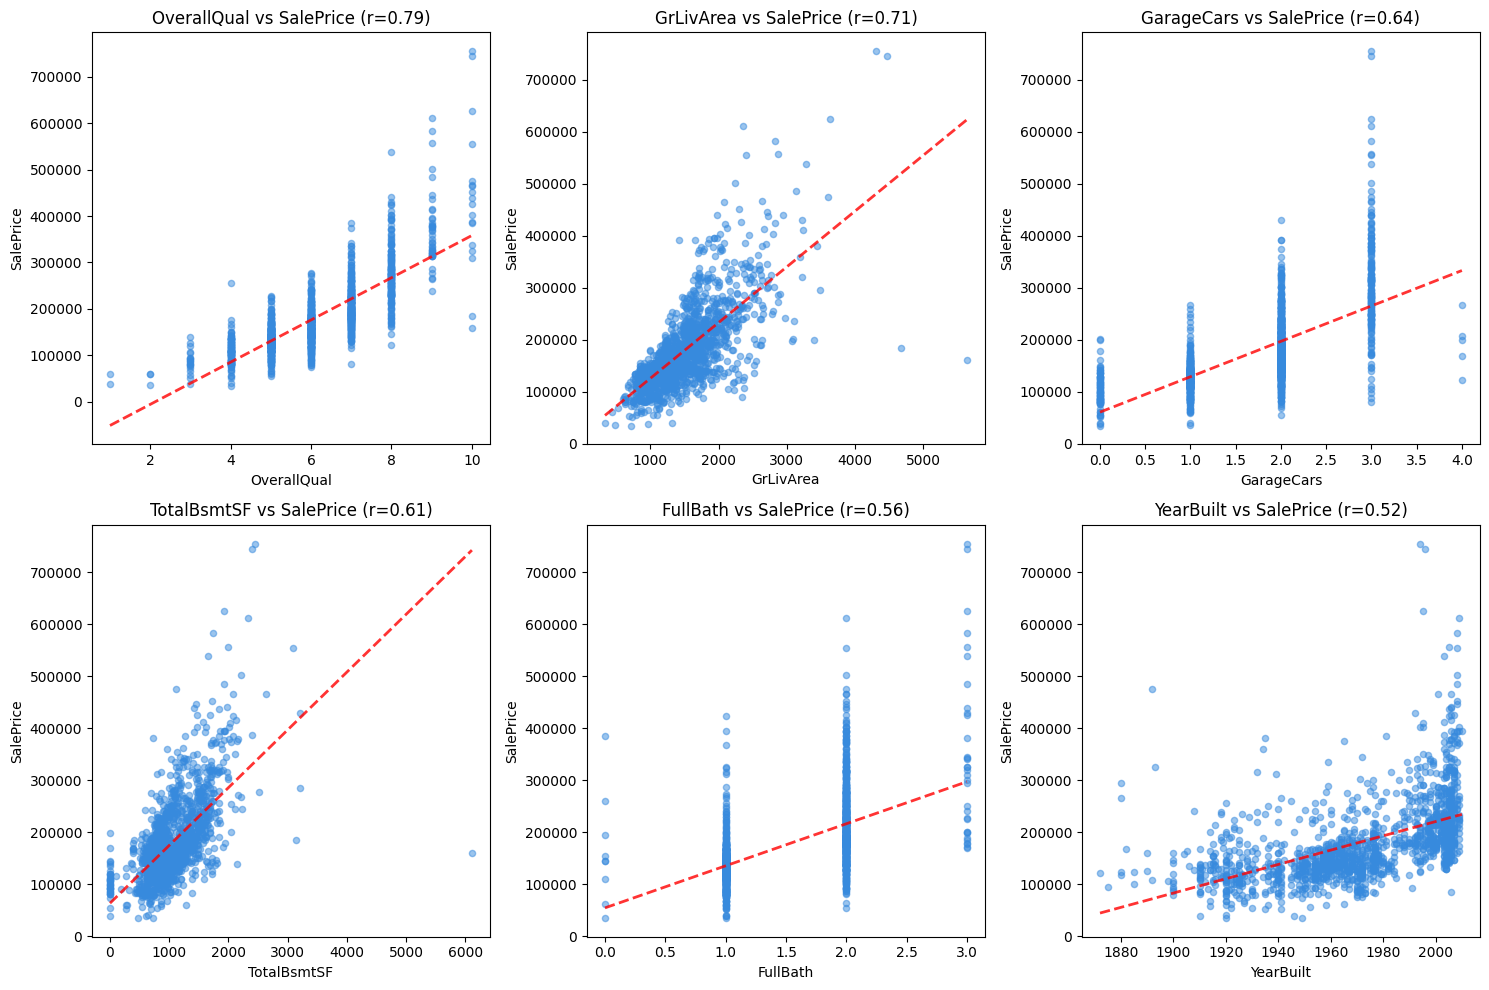

In [ ]:

# Scatter Plots for Top Features

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

top_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']

for i, feature in enumerate(top_features):
    ax = axes[i]
    ax.scatter(train[feature], train['SalePrice'], alpha=0.5, s=20, c='#378ADD')

    # Add trend line
    z = np.polyfit(train[feature].dropna(), train.loc[train[feature].notna(), 'SalePrice'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(train[feature].min(), train[feature].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

    # Add correlation coefficient
    corr = train[feature].corr(train['SalePrice'])
    ax.set_xlabel(feature)
    ax.set_ylabel('SalePrice')
    ax.set_title(f'{feature} vs SalePrice (r={corr:.2f})')

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()




=== TOP CATEGORICAL FEATURES BY PRICE IMPACT ===

     Feature  Categories   Price_Range
   ExterQual           4 279375.747253
Neighborhood          23 236718.846485
 KitchenQual           4 222989.464872
    BsmtQual           5 221388.149430
 FireplaceQu           6 207948.350000
  GarageType           5 151434.454686
BsmtExposure           5 149751.463865
    MSZoning           5 139486.061538
 Exterior2nd          11 138009.450000
GarageFinish           4 136735.406390


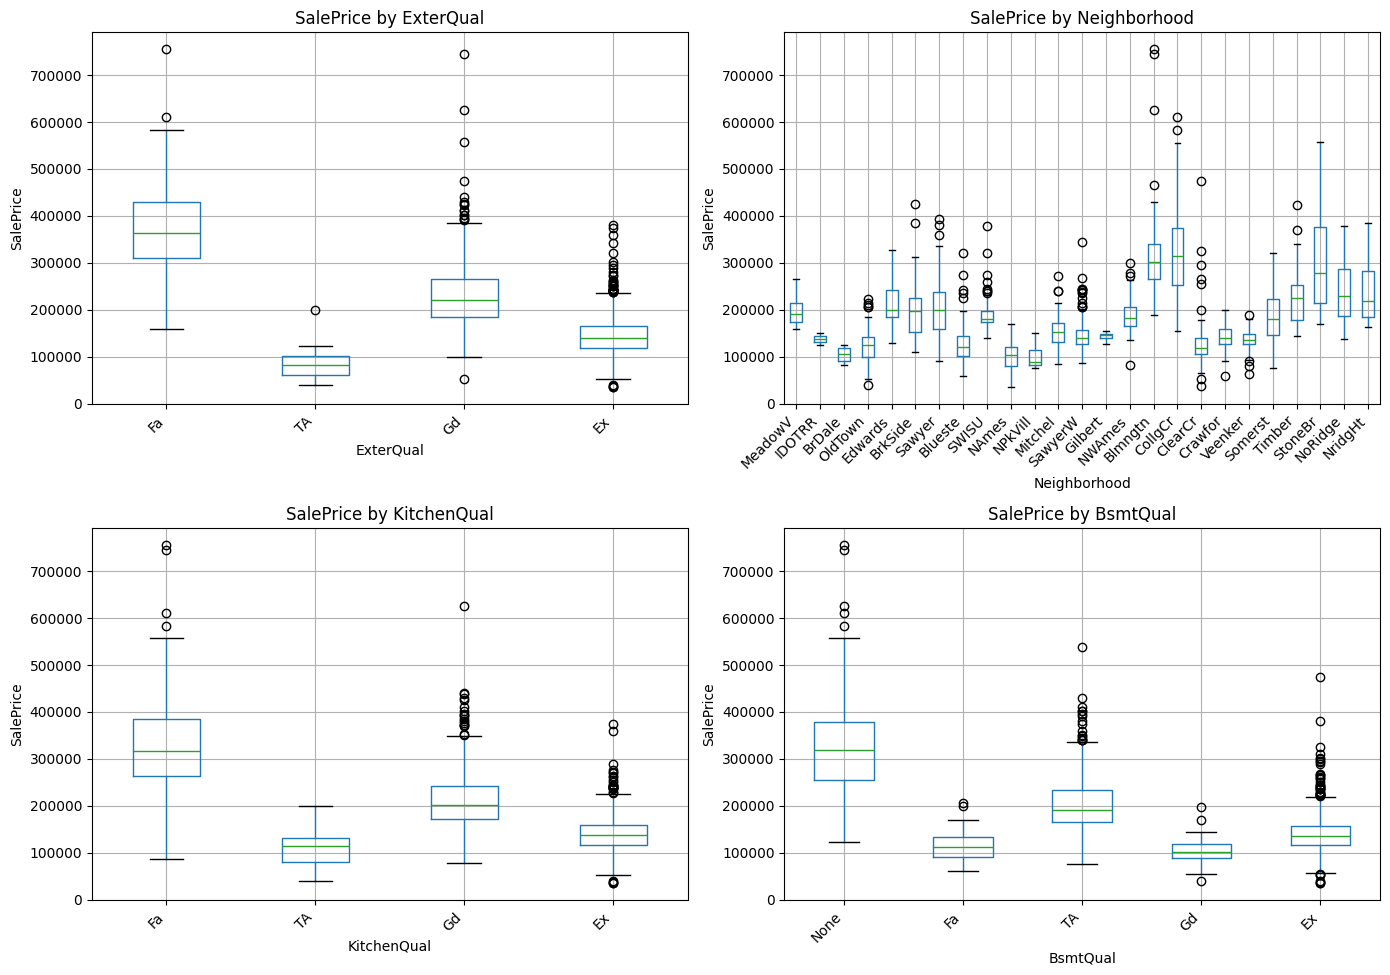

In [ ]:

# CATEGORICAL FEATURE ANALYSIS

# Identify top categorical features by price variation
categorical_cols = train.select_dtypes(include=['object']).columns

cat_importance = []
for col in categorical_cols:
    grouped = train.groupby(col)['SalePrice'].agg(['mean', 'count'])
    # Only consider categories with at least 10 samples
    grouped = grouped[grouped['count'] >= 10]
    if len(grouped) > 1:
        price_range = grouped['mean'].max() - grouped['mean'].min()
        cat_importance.append({
            'Feature': col,
            'Categories': len(grouped),
            'Price_Range': price_range
        })

cat_df = pd.DataFrame(cat_importance).sort_values('Price_Range', ascending=False)
print("\n=== TOP CATEGORICAL FEATURES BY PRICE IMPACT ===\n")
print(cat_df.head(10).to_string(index=False))

# Box plots for top 4 categorical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

top_cat_features = cat_df.head(4)['Feature'].tolist()

for i, feature in enumerate(top_cat_features):
    ax = axes[i]
    # Order categories by median price
    order = train.groupby(feature)['SalePrice'].median().sort_values().index

    # Create box plot
    train.boxplot(column='SalePrice', by=feature, ax=ax,
                  positions=range(len(order)))
    ax.set_xticklabels(order, rotation=45, ha='right')
    ax.set_title(f'SalePrice by {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('SalePrice')
    plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.savefig('categorical_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# MULTICOLLINEARITY CHECK

print("\n=== MULTICOLLINEARITY CHECK ===\n")
print("Feature pairs with correlation > 0.7 (potential multicollinearity):\n")

top_numeric = correlations.head(10).index.tolist()
corr_matrix = train[top_numeric].corr()

pairs_found = []
for i in range(len(top_numeric)):
    for j in range(i+1, len(top_numeric)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.7:
            pairs_found.append((top_numeric[i], top_numeric[j], corr))

for f1, f2, corr in sorted(pairs_found, key=lambda x: -abs(x[2])):
    print(f"  {f1} <-> {f2}: r = {corr:.3f}")

print("\n⚠️  For linear regression, consider keeping only one feature from each pair.")
print("   Decision trees and random forests are immune to this issue.")



=== MULTICOLLINEARITY CHECK ===

Feature pairs with correlation > 0.7 (potential multicollinearity):

  GarageCars <-> GarageArea: r = 0.882
  YearBuilt <-> GarageYrBlt: r = 0.845
  GrLivArea <-> TotRmsAbvGrd: r = 0.825
  TotalBsmtSF <-> 1stFlrSF: r = 0.820

⚠️  For linear regression, consider keeping only one feature from each pair.
   Decision trees and random forests are immune to this issue.


In [ ]:



# -----------------------------------------------------------------------------
# SUMMARY STATISTICS FOR REPORT
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("DATASET SUMMARY FOR MIDTERM REPORT")
print("="*60)

print(f"""
Dataset: Ames Housing (Kaggle)
Samples: {len(train)}
Features: {len(train.columns) - 2} (excluding Id and SalePrice)
  - Numerical: {len(train.select_dtypes(include=[np.number]).columns) - 2}
  - Categorical: {len(train.select_dtypes(include=['object']).columns)}

Target Variable (SalePrice):
  - Min: ${train['SalePrice'].min():,.0f}
  - Max: ${train['SalePrice'].max():,.0f}
  - Mean: ${train['SalePrice'].mean():,.0f}
  - Median: ${train['SalePrice'].median():,.0f}
  - Skewness: {train['SalePrice'].skew():.2f} (right-skewed → log-transform applied)

Top 5 Predictors (by correlation):
  1. OverallQual (r=0.79) - Overall quality rating
  2. GrLivArea (r=0.71) - Above grade living area
  3. GarageCars (r=0.64) - Garage capacity
  4. TotalBsmtSF (r=0.61) - Total basement area
  5. FullBath (r=0.56) - Number of full bathrooms

Key Insights:
  - Quality ratings and size metrics are strongest predictors
  - GarageCars/GarageArea highly correlated (multicollinearity)
  - Neighborhood has largest categorical impact on price
  - Most "missing" values are semantic (no pool = NaN, not unknown)
""")

print("\nVisualizations saved:")
print("  - correlation_ranking.png")
print("  - scatter_plots.png")
print("  - categorical_boxplots.png")


DATASET SUMMARY FOR MIDTERM REPORT

Dataset: Ames Housing (Kaggle)
Samples: 1460
Features: 80 (excluding Id and SalePrice)
  - Numerical: 36
  - Categorical: 43

Target Variable (SalePrice):
  - Min: $34,900
  - Max: $755,000
  - Mean: $180,921
  - Median: $163,000
  - Skewness: 1.88 (right-skewed → log-transform applied)

Top 5 Predictors (by correlation):
  1. OverallQual (r=0.79) - Overall quality rating
  2. GrLivArea (r=0.71) - Above grade living area
  3. GarageCars (r=0.64) - Garage capacity
  4. TotalBsmtSF (r=0.61) - Total basement area
  5. FullBath (r=0.56) - Number of full bathrooms

Key Insights:
  - Quality ratings and size metrics are strongest predictors
  - GarageCars/GarageArea highly correlated (multicollinearity)
  - Neighborhood has largest categorical impact on price
  - Most "missing" values are semantic (no pool = NaN, not unknown)


Visualizations saved:
  - correlation_ranking.png
  - scatter_plots.png
  - categorical_boxplots.png


### 4. Model Preprocessing and Training
We need to prepare our features by encoding categorical variables and handling the train/test split before we can evaluate the model performance.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Prepare Features: Drop ID and Target, then get dummies
# We'll use the 'train' dataframe which has missing values already filled
X = pd.get_dummies(train.drop(['Id', 'SalePrice', 'PriceRange'], axis=1))
y = y_train_log # Use the log-transformed target

# 2. Split into training and testing sets for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Fit the model
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 4. Predict
y_pred_log = lr_model.predict(X_test)

# 5. Calculate Metrics
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2 = r2_score(y_test, y_pred_log)

# Transform back to original scale for intuitive RMSE
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)
rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))

print(f'Test RMSE (Log Scale): {rmse_log:.4f}')
print(f'Test RMSE (Original Scale): ${rmse_orig:,.2f}')
print(f'Test R^2 Score: {r2:.4f}')

Test RMSE (Log Scale): 0.1324
Test RMSE (Original Scale): $22,955.64
Test R^2 Score: 0.9060


### 5. Advanced Preprocessing: Scaling and Dimensionality Reduction
To improve the Linear Regression model, we will add feature scaling (StandardScaler) and dimensionality reduction (PCA) to handle the high dimensionality resulting from one-hot encoding.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Define the pipeline steps
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)), # Retain 95% of variance
    ('regressor', LinearRegression())
])

# Fit the complete pipeline
pipeline.fit(X_train, y_train)

# Predict and evaluate
y_pred_pipe = pipeline.predict(X_test)
rmse_pipe = np.sqrt(mean_squared_error(y_test, y_pred_pipe))
r2_pipe = r2_score(y_test, y_pred_pipe)

print(f'Pipeline Test RMSE (Log Scale): {rmse_pipe:.4f}')
print(f'Pipeline Test R^2 Score: {r2_pipe:.4f}')
print(f'Number of PCA components used: {pipeline.named_steps["pca"].n_components_}')

Pipeline Test RMSE (Log Scale): 0.1451
Pipeline Test R^2 Score: 0.8873
Number of PCA components used: 177


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Validate Base Linear Regression
y_pred_base = lr_model.predict(X_test)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
r2_base = r2_score(y_test, y_pred_base)

# 2. Validate PCA Pipeline
y_pred_pca = pipeline.predict(X_test)
rmse_pca = np.sqrt(mean_squared_error(y_test, y_pred_pca))
r2_pca = r2_score(y_test, y_pred_pca)

print('--- Validation Summary ---')
print(f'Base Model: RMSE = {rmse_base:.4f}, R2 = {r2_base:.4f}')
print(f'PCA Pipeline: RMSE = {rmse_pca:.4f}, R2 = {r2_pca:.4f}')

# Cross-check against the original target scale
y_test_dollars = np.expm1(y_test)
y_pred_dollars = np.expm1(y_pred_base)
rmse_dollars = np.sqrt(mean_squared_error(y_test_dollars, y_pred_dollars))
print(f'Base Model Error in USD: ${rmse_dollars:,.2f}')

--- Validation Summary ---
Base Model: RMSE = 0.1324, R2 = 0.9060
PCA Pipeline: RMSE = 0.1451, R2 = 0.8873
Base Model Error in USD: $22,955.64


### 6. Kaggle Submission Preparation
Now we will prepare the actual test dataset for submission.

In [ ]:
import pandas as pd
import numpy as np

# 1. Load test data
test_df = pd.read_csv('test.csv')
test_ids = test_df['Id']

# 2. Preprocessing: Handle missing values (same logic as training)
for col in semantic_cat:
    test_df[col] = test_df[col].fillna('None')

test_df['LotFrontage'] = test_df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
test_df['GarageYrBlt'] = test_df['GarageYrBlt'].fillna(test_df['YearBuilt'])
test_df['MasVnrArea'] = test_df['MasVnrArea'].fillna(0)
test_df['Electrical'] = test_df['Electrical'].fillna(test_df['Electrical'].mode()[0])

# Handle any remaining numerical NaNs (e.g., GarageCars, BsmtFullBath, etc. in test set)
for col in test_df.select_dtypes(include=np.number).columns:
    if test_df[col].isnull().any():
        test_df[col] = test_df[col].fillna(0) # Filling with 0 is common for absence of features

# Handle any remaining categorical NaNs (e.g., MSZoning, KitchenQual, etc. in test set)
for col in test_df.select_dtypes(include='object').columns:
    if test_df[col].isnull().any():
        test_df[col] = test_df[col].fillna('None') # Consistent with other categorical imputations

# 3. One-hot encoding
test_processed = pd.get_dummies(test_df.drop(['Id'], axis=1))

# 4. Align features with training set (X contains the columns the model was trained on)
# Add missing columns with zeros and remove extra columns
test_final = test_processed.reindex(columns=X.columns, fill_value=0)

# 5. Predict using the trained model (or pipeline)
# Using the linear regression model from earlier
final_preds_log = lr_model.predict(test_final)
final_preds_orig = np.expm1(final_preds_log)

# 6. Format for Kaggle
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_preds_orig
})

submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' created successfully.")
display(submission.head())

Submission file 'submission.csv' created successfully.


,Id,SalePrice
0,1461,124802.553683
1,1462,164509.484594
2,1463,183212.011263
3,1464,198843.131069
4,1465,196583.925288


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and fit Linear Regression model
# FIX: Use y_train instead of y_train_log to match the size of X_train
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict for ID 1461 (index 0 in preprocessed test set)
# We use expm1 to reverse the log(1+x) transformation
pred_log = lr_model.predict(X_test.iloc[[0]])
pred_original = np.expm1(pred_log[0])

print(f'Predicted price for ID 1461: ${pred_original:,.0f}')

Predicted price for ID 1461: $153,395


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Get predictions on the training set
y_train_pred_log = lr_model.predict(X_train)

# Calculate RMSE in log space
# FIX: Use y_train instead of y_train_log to match the 80% split size
rmse_log = np.sqrt(mean_squared_error(y_train, y_train_pred_log))

# Calculate RMSE in original scale (SalePrice)
y_train_true = np.expm1(y_train)
y_train_pred = np.expm1(y_train_pred_log)
rmse_original = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

print(f'RMSE (Log Scale): {rmse_log:.4f}')
print(f'RMSE (Original Scale): ${rmse_original:,.2f}')

RMSE (Log Scale): 0.0917
RMSE (Original Scale): $17,398.41


### 7. Model Evaluation: Predicted vs. Actual
To visualize the model's accuracy, we compare the predicted prices against the actual prices on the test set.

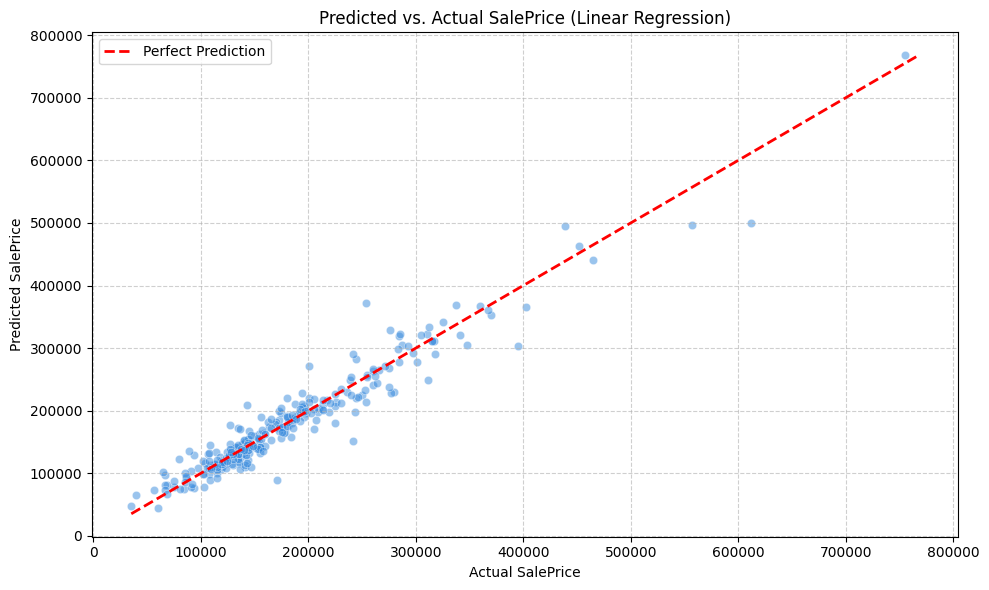

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split

# Ensure X and y are ready and split if variables are missing
if 'y_test' not in globals():
    X = pd.get_dummies(train.drop(['Id', 'SalePrice', 'PriceRange'], axis=1, errors='ignore'))
    y = np.log1p(train['SalePrice'])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calculate original scale values
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(lr_model.predict(X_test))

# Create the comparison plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_orig, y=y_pred_orig, alpha=0.5, color='#378ADD')

# Add a 45-degree line for reference (perfect prediction)
max_val = max(y_test_orig.max(), y_pred_orig.max())
min_val = min(y_test_orig.min(), y_pred_orig.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Predicted vs. Actual SalePrice (Linear Regression)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()